# Day 5: Machine Learning Workflow

This is where the week comes together. You framed a problem on Day 1, prepared data through Day 3, and explored it on Day 4. Today you build a real model, evaluate it honestly, save it for reuse, and see the same workflow applied to a second kind of problem.

## What you will learn

**Core concepts**
- The end to end machine learning workflow
- Train and test splits, and why holding out data is non negotiable
- Fitting, predicting, and evaluating a regression model
- Saving a trained model to disk and reloading it to make new predictions
- Classification versus regression, with a first look at the confusion matrix, precision, recall, and F1


**Technical tools**
- `scikit-learn` (`train_test_split`, model fit and predict, metrics)
- `pandas`, `matplotlib`, `seaborn`
- `joblib` (save a trained model, reload it elsewhere)

**Models covered**
- Linear Regression (a linear model for a numeric target)
- K-Nearest Neighbors (a distance based model for a categorical target)

We use it to predict monthly quantity sold (demand) from price and other features, the problem we framed on Day 1: given a price, how much would we expect to sell?

## Additional reading
- scikit-learn *Getting started*: https://scikit-learn.org/stable/getting_started.html
- Google *Machine Learning Crash Course*: https://developers.google.com/machine-learning/crash-course
- *An Introduction to Statistical Learning* (free PDF): https://www.statlearning.com/
- scikit-learn, *Model persistence*: https://scikit-learn.org/stable/model_persistence.html
- Analytics Vidhya, *Confusion Matrix in Machine Learning*: https://www.analyticsvidhya.com/blog/2020/04/confusion-matrix-machine-learning/


## Note

If you feel like some ML terms such as confusion matrix, precision, recall, train data, test data, etc. are difficult to understand, do not worry. Just hold on to these terms, note them down and approach the coming weeks with genuine curiosity. You will develop a better understanding because the next two weeks are action-packed with Machine Learning concepts and these terms will be broken down for you.


In [2]:
%pip install scikit-learn seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

def load_retail_price():
    candidates = ["W2_Data/retail_price.csv", "retail_price.csv", "../W2_Data/retail_price.csv"]
    for path in candidates:
        if Path(path).exists():
            return pd.read_csv(path)
    raise FileNotFoundError(
        "Could not find retail_price.csv. Adjust path to dataset."
    )


retail = load_retail_price()
print("Shape:", retail.shape)
retail.head()

Shape: (676, 30)


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


## 1. The machine learning workflow

Every supervised project follows the same steps. Memorise this loop.

1. **Frame**: define the target and the task. Here: predict `qty` (regression, a number).
2. **Prepare features**: choose input columns and put them in numeric form.
3. **Split**: separate data into a training set and a test set.
4. **Choose a model**: pick an algorithm to start with.
5. **Fit**: let the model learn from the training set.
6. **Predict**: apply it to the held out test set.
7. **Evaluate**: measure performance on data the model never saw.
8. **Iterate**: change features or model and repeat.

The whole point is step 7: performance on unseen data. That is the only honest measure of whether a model learned a real pattern, and in pricing specifically, whether it has actually captured the demand curve rather than memorised the history of a few products.

## 2. Prepare features and target

The **target** (`y`) is what we predict: `qty`, the quantity sold in a product-month. The **features** (`X`) are the inputs: price, freight, competitor prices, product attributes, and calendar counts, all already numeric.

In [3]:
features = ["unit_price", "freight_price", "product_score", "product_weight_g",
            "customers", "weekday", "weekend", "holiday",
            "comp_1", "comp_2", "comp_3", "lag_price"]

X = retail[features]
y = retail["qty"]

print("X shape:", X.shape)
print("Target summary:")
print(y.describe().round(1))

X shape: (676, 12)
Target summary:
count    676.0
mean      14.5
std       15.4
min        1.0
25%        4.0
50%       10.0
75%       18.0
max      122.0
Name: qty, dtype: float64


## 3. Train and test split

If you test a model on the same data it learned from, it can score well by memorising, not by learning a general rule. To catch that, you hold out a **test set** that the model never sees during training.

`train_test_split` shuffles and divides the data. We keep 25 percent for testing. `random_state` makes the split reproducible.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 507
Test rows: 169


## 4. Model: Linear Regression

**Linear Regression** learns a weighted combination of the features that best predicts the target. It is fast, and its coefficients are directly readable as "how much does predicted demand change per unit change in this feature," which matters a great deal in a pricing context where stakeholders want to understand the "why," not just the prediction.


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train, y_train)

pred_lr = linreg.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression MAE:", round(mae_lr, 2))
print("Linear Regression RMSE:", round(rmse_lr, 2))
print("Linear Regression R-squared:", round(r2_lr, 3))


Linear Regression MAE: 9.38
Linear Regression RMSE: 12.89
Linear Regression R-squared: 0.287


**MAE** (mean absolute error) is the average size of a miss, in units of `qty`, easy to explain to a non technical stakeholder. **RMSE** (root mean squared error) penalises large misses more heavily. **R-squared** is the share of the variation in demand the model explains, from 0 (no better than guessing the mean) to 1 (perfect).

In [6]:
# Which features move the prediction the most?
coefs = pd.Series(linreg.coef_, index=features).sort_values(key=abs, ascending=False)
coefs.round(2)

,0
product_score,2.84
holiday,1.33
freight_price,-0.38
unit_price,-0.21
lag_price,0.18
weekday,0.17
customers,0.11
comp_1,0.03
comp_3,-0.03
comp_2,0.02


## 5. Look at the errors, not just the summary numbers

A single error number can hide a lot. Plotting predicted versus actual values shows where the model struggles: does it consistently under-predict high-demand months, for example?


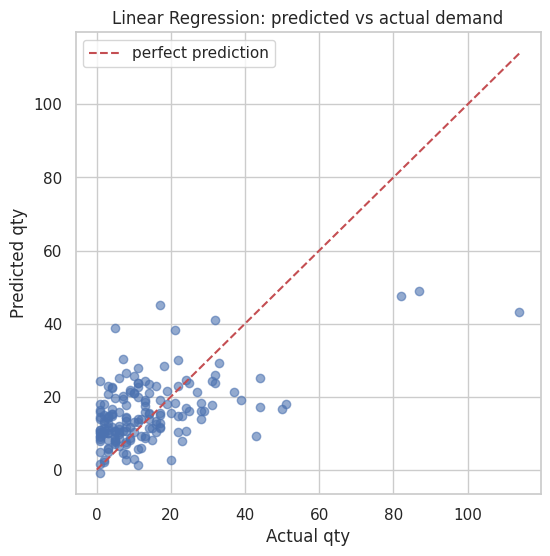

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_lr, alpha=0.6)
lims = [0, max(y_test.max(), pred_lr.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual qty")
plt.ylabel("Predicted qty")
plt.title("Linear Regression: predicted vs actual demand")
plt.legend()
plt.show()

Points above the red line are over-predictions, points below are under-predictions. A model that is honest about its limits is more useful than one that looks good only on an average error number; a pricing decision based on a systematically over-predicted demand figure would overstate expected revenue.

## 6. Save, reload, and predict with the trained model

Training took a few seconds here, but a real model can take minutes or hours to fit, and it usually runs in a different process than the one that uses it, an API, a scheduled job, another notebook. You do not retrain from scratch before every prediction. You train once, save the fitted model to disk, and reload it wherever a prediction is needed.

`joblib` is the standard way to save a scikit-learn model. It stores the fitted object, including every learned coefficient, exactly as it is in memory.

In [8]:
import joblib

joblib.dump(linreg, "linreg_qty_model.joblib")
print("Model saved to linreg_qty_model.joblib")

Model saved to linreg_qty_model.joblib


**Reload it.** `joblib.load` reconstructs the exact fitted model. Nothing gets retrained, the coefficients are identical to the original.

In [9]:
loaded_model = joblib.load("linreg_qty_model.joblib")

print("Coefficients match original:", np.allclose(loaded_model.coef_, linreg.coef_))

Coefficients match original: True


**Predict with the reloaded model.** This is the step that matters in practice: whatever uses the model, a script, an API, a colleague, only needs the saved file and a row of features shaped like `X`. It does not need the training code or the training data.

In [10]:
new_row = X_test.iloc[[0]]
reloaded_pred = loaded_model.predict(new_row)[0]

print("Prediction from the reloaded model:", round(reloaded_pred, 1))
print("Prediction from the original model:", round(pred_lr[0], 1))

Prediction from the reloaded model: 28.3
Prediction from the original model: 28.3


## Exercise (10 to 15 minutes)

Build and evaluate your own regression model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Use only two features this time, to see the effect of feature choice
feat2 = ["unit_price", "customers"]
X2 = retail[feat2]
y2 = retail["qty"]

# Task 1: split X2, y2 into train and test (test_size=0.25, random_state=0).

# Task 2: scale the features with StandardScaler (fit on train, transform both).

# Task 3: train a KNeighborsRegressor (try n_neighbors=5) on the scaled training data.

# Task 4: predict on the test set and print the MAE and R-squared.

# Task 5 (reflection): this model uses only two features. In one comment,
#         say whether it beat or trailed the twelve feature models above, and why
#         that might be.

### Solution

In [ ]:
# Task 1
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=0)

# Task 2
sc = StandardScaler()
X2_train_s = sc.fit_transform(X2_train)
X2_test_s = sc.transform(X2_test)

# Task 3
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X2_train_s, y2_train)

# Task 4
pred = knn.predict(X2_test_s)
print("KNN (2 features) MAE:", round(mean_absolute_error(y2_test, pred), 2))
print("KNN (2 features) R-squared:", round(r2_score(y2_test, pred), 3))

# Task 5
# Usually weaker than the twelve feature models: dropping freight, competitor
# prices, and calendar effects removes information that helps explain demand
# beyond just price and customer count.


## Part 2: A first look at classification, K-Nearest Neighbors

Everything above predicted a number, quantity sold. Many real problems instead ask for a category: spam or not spam, churn or stay, which species of flower. That is **classification**. The workflow from section 1 still applies, frame, prepare, split, choose, fit, predict, evaluate, iterate, only the target type and the evaluate step change.

We switch datasets here because the retail data has no natural category to predict. The **Iris** dataset is a classic: 150 flowers, 4 measurements each (sepal length, sepal width, petal length, petal width), labeled with one of 3 species. The task: given a flower's measurements, predict whether it is *Iris virginica* or one of the other two species.

**K-Nearest Neighbors (KNN)** makes no assumption about the shape of the data. To classify a new point, it looks at the `k` closest points in the training set and takes a majority vote of their labels.

This is a first look. Confusion matrices, precision, recall, and F1 get a full treatment, with far more nuance, later in the bootcamp.

In [11]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
Xc = iris.data
yc = (iris.target == 2).astype(int)  # 1 = virginica, 0 = the other two species

print("Xc shape:", Xc.shape)
print("Class balance (1 = virginica):")
print(yc.value_counts())

Xc shape: (150, 4)
Class balance (1 = virginica):
target
0    100
1     50
Name: count, dtype: int64


**Split, same idea as before.** 30 percent held out for testing, `random_state` fixed for reproducibility.

In [12]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.3, random_state=2018
)

print("Training rows:", len(Xc_train))
print("Test rows:", len(Xc_test))

Training rows: 105
Test rows: 45


**Model: K-Nearest Neighbors.** `n_neighbors=10` means each prediction is a vote among the 10 closest training flowers. A small `k` follows the local data closely and can overfit to noise, a large `k` smooths the decision but can blur real boundaries between classes.

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(Xc_train, yc_train)

pred_knn = knn.predict(Xc_test)

## 7. Evaluate: measure performance on data the model never saw

Regression used MAE, RMSE, and R-squared. Classification needs different metrics, a prediction is either right or wrong, there is no notion of "close."

**Accuracy** is the fraction of predictions that were correct. It can mislead on imbalanced classes, always predicting "not virginica" would already score well here, since two of the three species fall into that class.

The **confusion matrix** breaks a set of predictions into four counts: how many of each actual class got predicted as each class. From those four counts:

- **Precision**: of everything predicted virginica, how much actually was. This is what matters when a false positive is costly.
- **Recall**: of everything that actually was virginica, how much got caught. This is what matters when a false negative is costly.
- **F1**: the harmonic mean of precision and recall, one number when both matter.

Note: we will recover these topics, and go deeper on when to favor precision over recall, later in the bootcamp.

Accuracy:  0.956
Precision: 1.000
Recall:    0.875
F1 score:  0.933


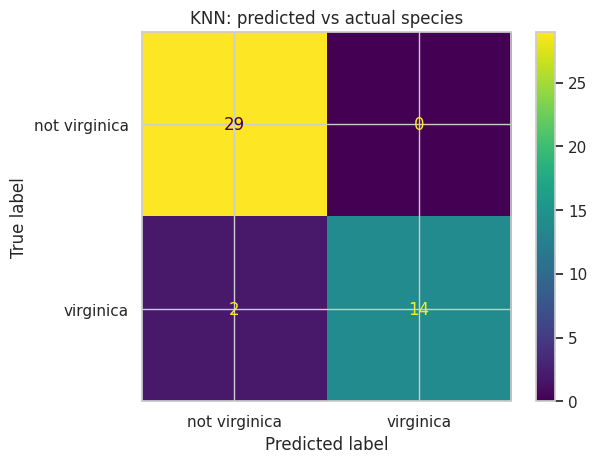

In [14]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

acc = accuracy_score(yc_test, pred_knn)
prec = precision_score(yc_test, pred_knn)
rec = recall_score(yc_test, pred_knn)
f1 = f1_score(yc_test, pred_knn)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")

cm = confusion_matrix(yc_test, pred_knn)
ConfusionMatrixDisplay(cm, display_labels=["not virginica", "virginica"]).plot()
plt.title("KNN: predicted vs actual species")
plt.show()

Notice how little changed in the workflow itself. The difference between predicting a number and predicting a category was the model and the evaluate step. That pattern, same skeleton, different tools depending on the target, is what lets you pick up new algorithms quickly for the rest of the bootcamp.

## Recap

- The ML workflow is a fixed loop: frame, prepare, split, choose, fit, predict, evaluate, iterate. It applies whether the target is a number or a category.
- A held out test set is the only honest measure of performance. Never train on it, and never let it leak into preparation.
- Linear Regression predicts demand here; judge it with MAE, RMSE, and R-squared, and look at predicted-versus-actual plots, not a single summary number.
- A trained model is just an object. Save it with `joblib`, reload it anywhere, and it predicts exactly as it did when trained.
- Classification predicts a category. Accuracy alone can mislead, the confusion matrix and precision, recall, and F1 give a fuller picture. Week 4 goes much deeper here.

That closes Week 2. You can now take a business question like "are we pricing this right," shape it into a data problem, prepare and explore the data, and build and judge a model to answer it, whether the answer is a number or a category.

## Tip

In Data Science, curiosity is key. You should learn to ask just the right questions with just enough curiosity and the data will tell you everything there is to know about it.